In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

In [38]:
df_us_da=df[(df['job_country']=="United States") & (df['job_title_short']=="Data Analyst")].copy()

In [16]:
def clean(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)

In [15]:
import ast

In [39]:
df_us_da['job_skills']=df_us_da['job_skills'].apply(clean)

In [42]:
df_us_da_explode=df_us_da.explode('job_skills')

In [44]:
df_us_da_explode['job_posted_date']=pd.to_datetime(df_us_da_explode['job_posted_date'])

In [45]:
df_us_da_explode['job_posted_month']=df_us_da_explode['job_posted_date'].dt.month

In [82]:
df_pivot=df_us_da_explode.pivot_table(index='job_posted_month',columns='job_skills',aggfunc='size',fill_value=0)

In [65]:
df_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,asp.net core,...,watson,webex,windows,wire,word,workfront,wrike,xamarin,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,39,7,206,21,7,1,0,15,17,0,...,7,9,80,3,968,0,7,0,0,30
2,35,0,203,23,4,1,0,14,9,0,...,6,6,92,3,738,3,0,0,0,19
3,39,1,219,5,5,6,1,14,11,0,...,7,6,76,5,736,1,1,1,0,16
4,28,1,208,8,3,7,3,5,6,0,...,2,4,86,9,695,8,1,0,0,12
5,27,3,144,15,8,9,1,5,13,0,...,1,6,67,1,557,3,0,0,0,9
6,39,5,188,9,4,8,3,7,7,0,...,5,2,69,8,721,5,0,0,0,20
7,42,2,160,5,3,5,5,6,2,0,...,4,1,59,10,587,0,0,0,1,13
8,44,2,187,5,3,10,0,5,3,0,...,3,6,87,4,752,0,0,0,0,26
9,22,3,145,11,2,3,4,4,3,0,...,0,4,80,4,478,0,0,0,1,12


In [83]:
df_pivot.loc['total']=df_pivot.sum()

In [84]:
df_pivot = df_pivot[df_pivot.loc['total'].sort_values(ascending=False).index]

In [87]:
df_pivot=df_pivot.drop('total')

In [75]:
help(plt)

Help on module matplotlib.pyplot in matplotlib:

NAME
    matplotlib.pyplot

DESCRIPTION
    `matplotlib.pyplot` is a state-based interface to matplotlib. It provides
    an implicit,  MATLAB-like, way of plotting.  It also opens figures on your
    screen, and acts as the figure GUI manager.

    pyplot is mainly intended for interactive plots and simple cases of
    programmatic plot generation::

        import numpy as np
        import matplotlib.pyplot as plt

        x = np.arange(0, 5, 0.1)
        y = np.sin(x)
        plt.plot(x, y)
        plt.show()

    The explicit object-oriented API is recommended for complex plots, though
    pyplot is still usually used to create the figure and often the Axes in the
    figure. See `.pyplot.figure`, `.pyplot.subplots`, and
    `.pyplot.subplot_mosaic` to create figures, and
    :doc:`Axes API </api/axes_api>` for the plotting methods on an Axes::

        import numpy as np
        import matplotlib.pyplot as plt

        x = np.arang

<Axes: xlabel='job_posted_month'>

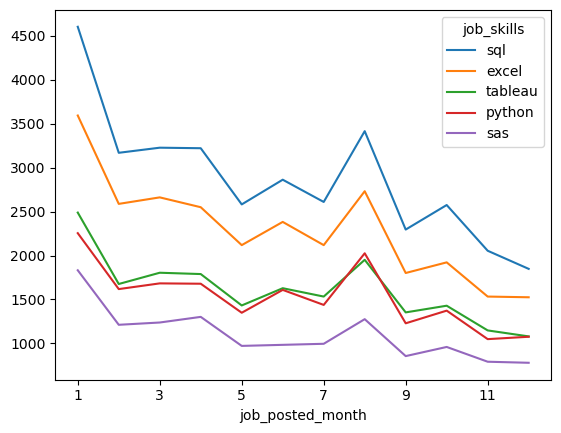

In [90]:
df_pivot.iloc[:, :5].plot(kind='line')